(100, 1)
(100, 1)


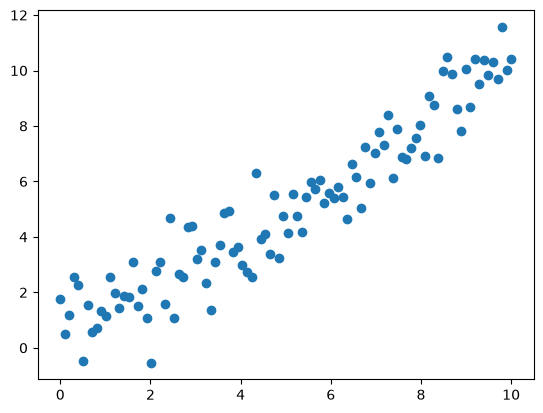

In [3]:
# présenter la structure de l'API scikit learn

# créer le dataset et le visualiser
import numpy as np 
import matplotlib.pyplot as plt 


# utiliser numpy pour créer le dataset
np.random.seed(0) # bloquer l'aléatoire

m = 100
# features ici 1 seule
X = np.linspace(0,10,m).reshape(m,1)
y = X + np.random.randn(m,1)

print(X.shape) # (100, 1)
print(y.shape) # (100, 1)
plt.scatter(X, y)

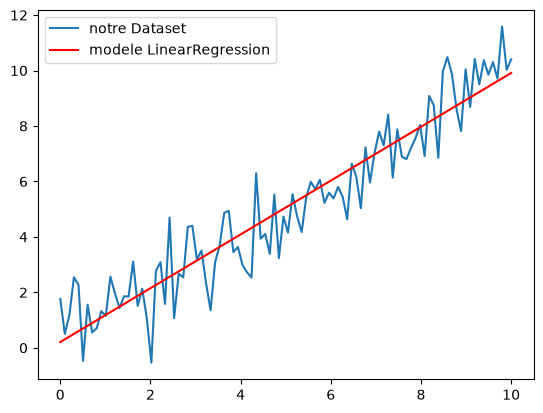

In [10]:
from sklearn.linear_model import LinearRegression

# créer le modèle
model = LinearRegression()

# entrainement
model.fit(X , y)

# évaluer la performance du notre modèle
model.score(X, y ) # 88,8% 

y_predict = model.predict( X )

plt.plot(X, y , label="notre Dataset")
plt.plot( X , y_predict , color="r" , label="modele LinearRegression")
plt.legend()


Utiliser scikit learn pour de la classification Utilisation du dataset du titanic

In [12]:
import sys
!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
# dataset récupérer nos données

import seaborn as sns
import numpy as np

titanic = sns.load_dataset("titanic")

titanic.shape # numpy (891, 15)
titanic.head() # pandas

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
titanic = titanic[["survived" , "pclass" , "sex" , "age" ]]

# transformer male en 0 et female en 1
# les modèles ne comprennent pas les textes
titanic["sex"] = titanic["sex"].map({ 'male' : 0 , 'female' : 1 })

titanic.dropna(axis=0, inplace=True)

titanic.describe()

y = titanic["survived"]
y = y.values.reshape(-1,1) # transformer les dimensions du vecteur
                           # (714,) => (714,1)
                           # Eviter les opérations de Broadcasting 

X = titanic.drop( ["survived"], axis=1 ) # (714, 3)

# verifier les dimensions  de X et y

# utilisation de scikit-learn
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()

# apprendre
model.fit( X, y ) 

# les valeurs trouvées après l'apprentissage 
# meta paramètre du modèle KNeighborsClassifier
# n_neighbours = 5
# metric = minkowski

# évaluer performance du modèle
model.score( X,y ) # 0.8417366946778712 


# est ce que l'on aurait survecu au Titanic
# tester notre modèle
def survie(model , pclass=2 , sex=0 , age=40):
    moi = np.array([pclass , sex, age]).reshape(1,3)
    print(model.predict_proba(moi)) # [[0.8 0.2]]
    return model.predict( moi )


survie(model) # [0] non


[[0.8 0.2]]


c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
# est ce que l'on aurait survecu au Titanic
# tester notre modèle
def survie(model , pclass=2 , sex=0 , age=40):
    moi = np.array([pclass , sex, age]).reshape(1,3)
    print(model.predict_proba(moi)) # [[0.8 0.2]]
    return model.predict( moi )

survie(model , pclass=3 , sex=1, age=20)

[[0.6 0.4]]


c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

# rendre notre modèle plus performant et plus fiable 
# dataset en 2 parties 

- data_train 
- data_test
- data_validation

rdv dans 15 min => 10h45 bon café !!!!!!! @ toute suite


En Machine Learning il ne faut JAMAIS évaluer la performance de votre modèle sur les données d'entrainement

model = KNeighborsClassifier()

# apprendre
model.fit( X, y ) # données d'entrainement (passager tous)

# les valeurs trouvées après l'apprentissage 
# meta paramètre du modèle KNeighborsClassifier
# n_neighbours = 5
# metric = minkowski

# évaluer performance du modèle
model.score( X,y ) # 0.8417366946778712  (réutiliser les mêmes données)

ce qu'il est conseillé de faire => découper le dataset en 2 parties 

X , y

une partie pour l'entrainenemt => 80%

X_train , y_train => model.fit( X_train, y_train )

une deuxieme partie pour les tests de performance => 20%

X_test , y_test   => model.score( X_test, y_test )

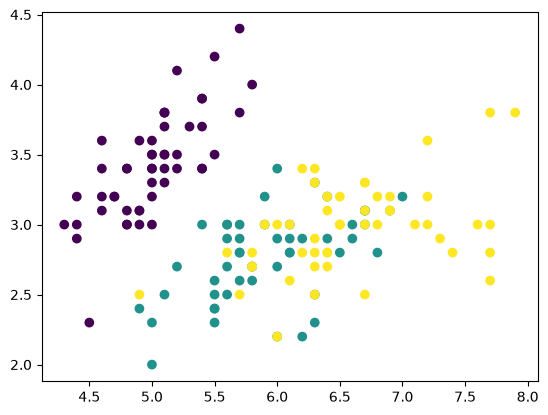

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris 

# Dataset complet

iris = load_iris()

X = iris.data
y = iris.target 

X.shape # (150, 4)
y = np.reshape(y,( y.shape[0] , 1)) # Broadcasting
y.shape  # (150,1)

plt.scatter(X[:,0],X[:,1], c=y )

C:\Users\harri\AppData\Local\Temp\ipykernel_9724\3250383570.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


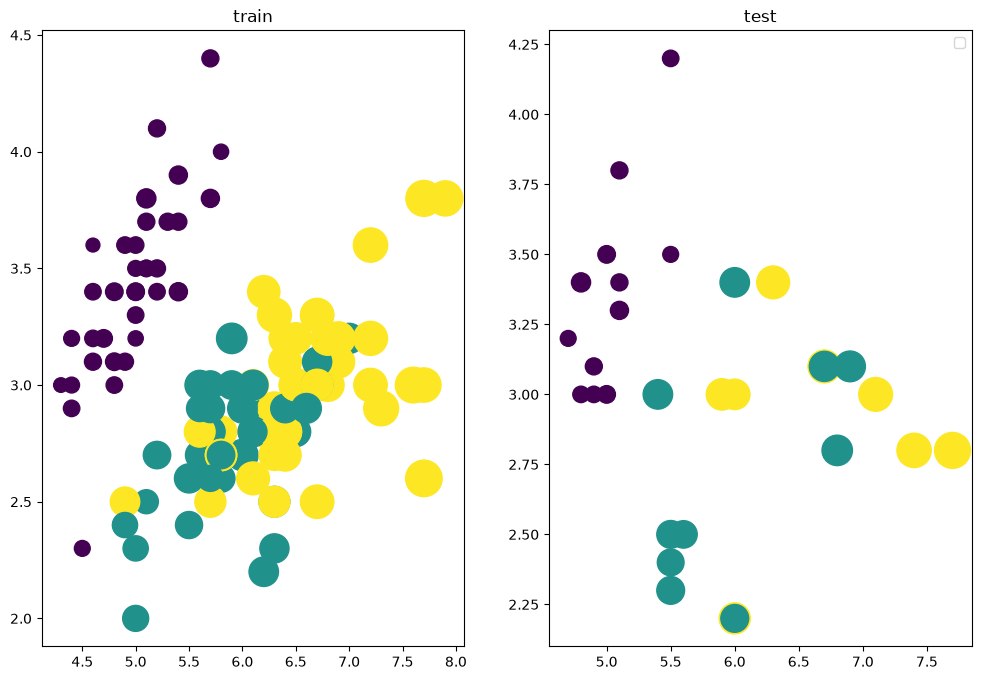

In [64]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train  , y_test = train_test_split(X,y, test_size=0.2)

# visualiser les nouveaux dataset

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.scatter(X_train[:,0], X_train[:,1] , c=y_train ,s=X_train[:,2]*100)
plt.title("train")

plt.subplot(1,2,2)
plt.scatter(X_test[:,0], X_test[:,1] , c=y_test ,s=X_test[:,2]*100)
plt.title("test")

plt.legend()


In [74]:
# réentrainer un modèle en utilisant des données train et test
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=6)

# entrainement

model.fit(X_train, y_train)

# evaluer notre modèle 

# model.score(X_train , y_train ) # 0.966
model.score(X_test , y_test ) # 0.966


c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.9333333333333333

Dans le train_set on va ajouter encore une nouvelle sous partie 
le validation_set
enlever une petite partie par exemple 1/5 du train set
qui va nous permettre d'entrainer notre model
ce train set va être tirer aléatoirement plusieurs fois (5 fois) dans le train set pour voir quel méta paramètre est le bon 

In [75]:
from sklearn.model_selection import cross_val_score

cross_val_score( KNeighborsClassifier() , X_train , y_train , cv=5 , scoring='accuracy' )

c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

array([0.95833333, 0.875     , 1.        , 0.95833333, 1.        ])

In [ ]:
cross_val_score( KNeighborsClassifier(1) , X_train , y_train , cv=5 , scoring='accuracy' ).mean() # 0.93
cross_val_score( KNeighborsClassifier(2) , X_train , y_train , cv=5 , scoring='accuracy' ).mean() # 0.9
cross_val_score( KNeighborsClassifier(3) , X_train , y_train , cv=5 , scoring='accuracy' ).mean() # 0.95

c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

np.float64(0.9583333333333333)

In [ ]:
# pour quelle valeur de l'hyperparamètre n_neighbors  de KNeighborsClassifier
# il y a la meilleure valeur pour le score du modele

c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

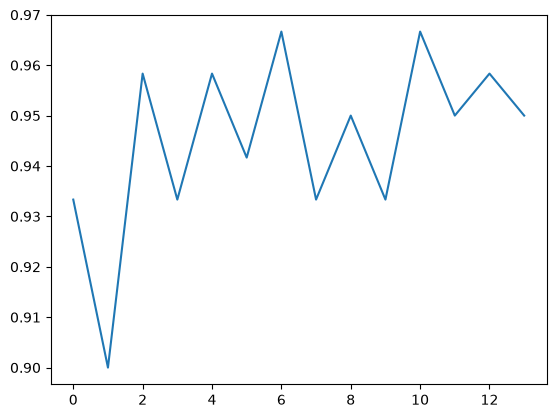

In [80]:
resultat = []
for n_neighbors in range(1, 15):
    mean = cross_val_score( KNeighborsClassifier(n_neighbors) , X_train , y_train , cv=5 , scoring='accuracy' ).mean()
    resultat.append(mean)

plt.plot(resultat)

In [86]:
model = KNeighborsClassifier(n_neighbors=11)

# entrainement

model.fit(X_train, y_train)

# evaluer notre modèle 

# model.score(X_train , y_train ) # 0.966
model.score(X_test , y_test ) # 0.966

c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.9666666666666667

c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

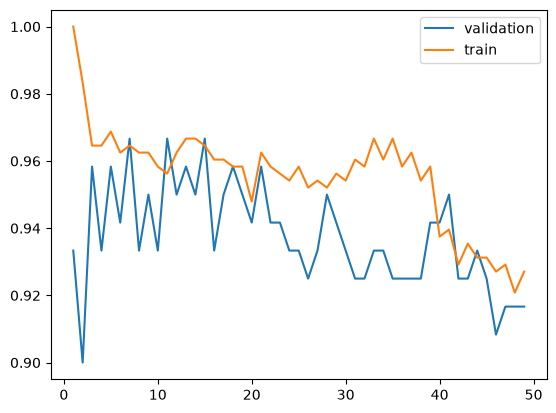

In [88]:
# validation curve 

from sklearn.model_selection import validation_curve

model = KNeighborsClassifier()
k = np.arange(1,50,1)

train_score , val_score = validation_curve( model, X_train , y_train , param_name='n_neighbors' , param_range=k , cv=5 )

plt.plot(k , val_score.mean(axis=1) , label="validation")
plt.plot(k , train_score.mean(axis=1) , label="train")
plt.legend()

est ce que l'on peut trouvé de meilleur meta paramètre qui vont améliorer notre score

In [89]:
model = KNeighborsClassifier()
model.fit(X_train, y_train)


c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
from sklearn.model_selection import GridSearchCV

hyper_params = {
    'n_neighbors' : np.arange(1,50, 1),
    'metric' : ['euclidean', 'manhattan', "minkowski"]
}

# grid qui va nous retourner la meilleur valeur parmis les hyper_params

grid = GridSearchCV(
    KNeighborsClassifier(),
    hyper_params ,
    cv=5
)

grid.fit(X_train, y_train)

grid.best_estimator_ # n_neighbors = 15 et metric = manhattan

model = grid.best_estimator_ # KNeighborsClassifier(n_neighbors=15, metric=manhattan)

model.score(X_test, y_test) # 0.96


c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\harri\Desktop\iot\.env\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please cha

0.9666666666666667